# Trade Exception Predictor - Complete Modelling Pipeline

**Objective:** Build, train, explain, and deploy a trade exception prediction model

**This notebook integrates:**
1. `features_updated.py` - Feature engineering (all 25 columns)
2. `train_updated.py` - XGBoost + Optuna training
3. `explain_updated.py` - SHAP explainability
4. `score_updated.py` - Azure ML inference service

**Pipeline:** Data → Features → Training → Evaluation → Explanation → Scoring

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Configure paths and imports
import sys
import os

# Add src to Python path (absolute path)
src_path = os.path.abspath(os.path.join(os.getcwd(), '../src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Import custom modules
from features import FeatureEngineering
from train import TradeExceptionPredictor
from explain import ExplainabilityAnalyzer
from score import TradeExceptionScoringService

import mlflow
import joblib

print("✓ Custom modules imported successfully")

✓ Custom modules imported successfully


In [3]:
# Configure MLflow
mlflow.set_tracking_uri('./mlflow_tracking')
mlflow.set_experiment('trade_exception_predictor')

print(f"✓ MLflow configured")
print(f"  URI: {mlflow.get_tracking_uri()}")
print(f"  Experiment: trade_exception_predictor")

✓ MLflow configured
  URI: ./mlflow_tracking
  Experiment: trade_exception_predictor


## 2. Load Data

In [4]:
# Load dataset
df = pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/hello_world/azure-xgb/trade_exception_predictor/data/trades_synthetic_1001.csv')


print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns ({df.shape[1]} total):")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")

Dataset loaded: 15,000 rows × 25 columns

Columns (25 total):
['trade_id', 'trade_date', 'settlement_date', 'days_to_settlement', 'commodity_type', 'instrument_type', 'delivery_location', 'counterparty_id', 'counterparty_tier', 'counterparty_region', 'notional_usd', 'quantity_mt', 'price_per_mt', 'settlement_currency', 'is_month_end', 'is_quarter_end', 'day_of_week', 'counterparty_exception_rate_30d', 'same_commodity_breaks_7d', 'price_volatility_flag', 'cross_border_flag', 'currency_mismatch_flag', 'documentation_lag_days', 'amendment_count', 'is_exception']

Data types:
object     11
int64      10
float64     4
Name: count, dtype: int64

Missing values: 0


In [5]:
# Display first few rows
print("First 3 rows:")
df.head(3)

First 3 rows:


,trade_id,trade_date,settlement_date,days_to_settlement,commodity_type,instrument_type,delivery_location,counterparty_id,counterparty_tier,counterparty_region,...,is_quarter_end,day_of_week,counterparty_exception_rate_30d,same_commodity_breaks_7d,price_volatility_flag,cross_border_flag,currency_mismatch_flag,documentation_lag_days,amendment_count,is_exception
0,TR_000001,2022-01-03,2022-01-05,2,Wheat,Futures,Rotterdam,CP_048,Tier2,South America,...,0,Monday,0.31,0,0,1,1,5,1,1
1,TR_000002,2022-01-03,2022-01-05,2,Soybean,Spot,Rotterdam,CP_006,Tier1,Europe,...,0,Monday,0.09,1,0,0,0,3,0,0
2,TR_000003,2022-01-03,2022-01-05,2,Soybean,Spot,Vancouver,CP_004,Tier1,Asia,...,0,Monday,0.32,0,0,1,0,2,0,0


## 3. Feature Engineering

In [6]:
# Initialize feature engineering
print("="*80)
print("STEP 1: FEATURE ENGINEERING")
print("="*80)

fe = FeatureEngineering(df)
X_train, X_test, y_train, y_test, feature_names = fe.engineer_features(test_size=0.2, random_state=42)

print(f"\n✓ Feature engineering complete!")
print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nFeature names ({len(feature_names)} total):")
print(feature_names)

STEP 1: FEATURE ENGINEERING

FEATURE ENGINEERING PIPELINE

1. Parsing dates...
2. Encoding categorical features...
3. Creating interaction features...
4. Scaling numeric features...
5. Cleaning non-feature columns...
6. Splitting data...

✓ FEATURE ENGINEERING COMPLETE

Dataset Summary:
  • Features: 21
  • Train samples: 12,000
  • Test samples: 3,000
  • Exception rate (train): 29.1%
  • Exception rate (test): 29.1%
  • scale_pos_weight: 2.44


✓ Feature engineering complete!

Feature matrix shapes:
  X_train: (12000, 21)
  X_test:  (3000, 21)

Feature names (21 total):
['days_to_settlement', 'counterparty_id', 'counterparty_tier', 'counterparty_region', 'notional_usd', 'quantity_mt', 'price_per_mt', 'is_month_end', 'is_quarter_end', 'counterparty_exception_rate_30d', 'same_commodity_breaks_7d', 'price_volatility_flag', 'cross_border_flag', 'currency_mismatch_flag', 'documentation_lag_days', 'amendment_count', 'tier_x_month_end', 'tier_x_doc_lag', 'high_doc_lag', 'high_amendments', '


Target distribution:
  Train: 29.1% exceptions
  Test:  29.1% exceptions


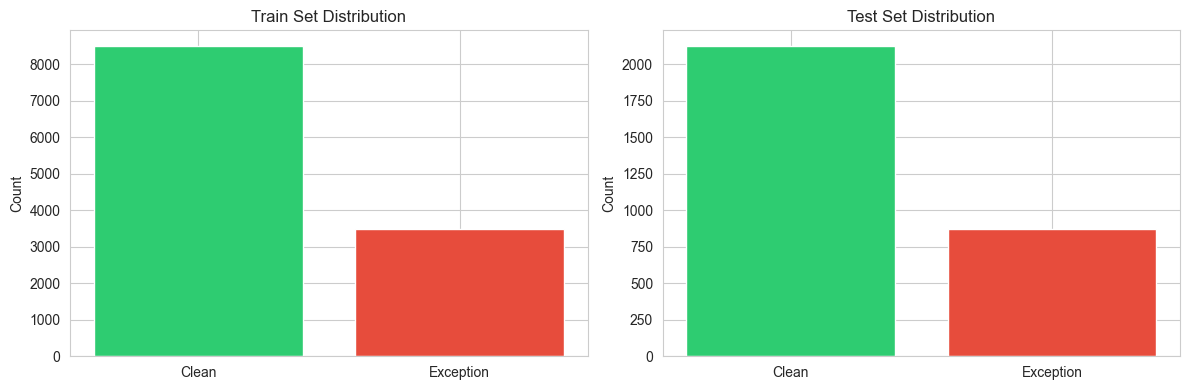

In [7]:
# Check target distribution
print("\nTarget distribution:")
print(f"  Train: {y_train.mean():.1%} exceptions")
print(f"  Test:  {y_test.mean():.1%} exceptions")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train distribution
train_counts = pd.Series(y_train).value_counts()
axes[0].bar(['Clean', 'Exception'], train_counts, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Train Set Distribution')
axes[0].set_ylabel('Count')

# Test distribution
test_counts = pd.Series(y_test).value_counts()
axes[1].bar(['Clean', 'Exception'], test_counts, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Model Training

In [8]:
print("="*80)
print("STEP 2: MODEL TRAINING")
print("="*80)

# Start MLflow run
with mlflow.start_run(run_name='xgboost_optuna_shap'):
    mlflow.set_tag('model_type', 'xgboost')
    mlflow.set_tag('objective', 'trade_exception_prediction')
    
    # Initialize and train predictor
    predictor = TradeExceptionPredictor(n_trials=50, random_state=42)
    predictor.train(X_train, y_train, X_test, y_test)
    
    # Log model
    mlflow.xgboost.log_model(predictor.model, 'xgboost_model')
    
    print(f"\n✓ Model trained and logged to MLflow")
    print(f"  Run ID: {mlflow.active_run().info.run_id}")

STEP 2: MODEL TRAINING


[I 2026-04-26 22:48:57,735] A new study created in memory with name: no-name-22256b57-8dc8-40cd-86f4-f52291f17bc5



╔==============================================================================╗
║                                                                              ║
║                     TRADE EXCEPTION PREDICTOR - TRAINING                     ║
║                                                                              ║
╚==============================================================================╝

┌─ CLASS IMBALANCE
├─ Clean trades:     8,508 (70.9%)
├─ Exceptions:       3,492 (29.1%)
└─ scale_pos_weight: 2.44

┌─ HYPERPARAMETER TUNING (Optuna - 50 trials)


Best trial: 0. Best value: 0.54685:   2%|▏         | 1/50 [00:02<02:00,  2.46s/it]

[I 2026-04-26 22:49:00,191] Trial 0 finished with value: 0.5468500504343059 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 393, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2}. Best is trial 0 with value: 0.5468500504343059.


...

[I 2026-04-26 22:49:24,302] Trial 48 finished with value: 0.5990793113791966 and parameters: {'max_depth': 5, 'learning_rate': 0.02711412005319742, 'n_estimators': 221, 'subsample': 0.9088743776116952, 'colsample_bytree': 0.6732502864412406, 'min_child_weight': 4}. Best is trial 25 with value: 0.6140178827716088.


Best trial: 25. Best value: 0.614018: 100%|██████████| 50/50 [00:27<00:00,  1.84it/s]


[I 2026-04-26 22:49:24,889] Trial 49 finished with value: 0.5906102254814686 and parameters: {'max_depth': 9, 'learning_rate': 0.011251630067095399, 'n_estimators': 181, 'subsample': 0.7683317833097935, 'colsample_bytree': 0.6251092933229088, 'min_child_weight': 1}. Best is trial 25 with value: 0.6140178827716088.
├─ Best Trial: #25
├─ Best AUC: 0.6140
└─ Best Parameters (showing top 6):
   ├─ colsample_bytree: 0.8069410260856267
   ├─ learning_rate: 0.012120433859534862
   ├─ max_depth: 3
   ├─ min_child_weight: 6
   └─ n_estimators: 308

┌─ TRAINING FINAL MODEL


2026/04/26 22:49:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


├─ Boosting rounds: 308
└─ ✓ Model trained

┌─ MODEL EVALUATION
├─ TEST METRICS:
│  ├─ AUC-ROC:   0.6140
│  ├─ Precision: 0.3768
│  ├─ Recall:    0.5430
│  └─ F1-Score:  0.4449
├─ TRAIN AUC:     0.6372
├─ ✓ Healthy model (gap: 0.0232)
└─ CONFUSION MATRIX:
   ├─ True Negatives:  1,343
   ├─ False Positives: 784
   ├─ False Negatives: 399
   └─ True Positives:  474

✓ TRAINING COMPLETE


✓ Model trained and logged to MLflow
  Run ID: 2c74f2ca36104cd5bd4675df49655652


## 5. Model Evaluation

In [9]:
print("="*80)
print("STEP 3: MODEL EVALUATION")
print("="*80)

# Get predictions
y_pred = predictor.predict(X_test)
y_pred_proba = predictor.predict_proba(X_test)[:, 1]

# Calculate metrics
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

test_auc = roc_auc_score(y_test, y_pred_proba)
test_prec = precision_score(y_test, y_pred)
test_rec = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f"\nTest Set Metrics:")
print(f"  AUC-ROC:   {test_auc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

STEP 3: MODEL EVALUATION

Test Set Metrics:
  AUC-ROC:   0.6140
  Precision: 0.3768
  Recall:    0.5430
  F1-Score:  0.4449


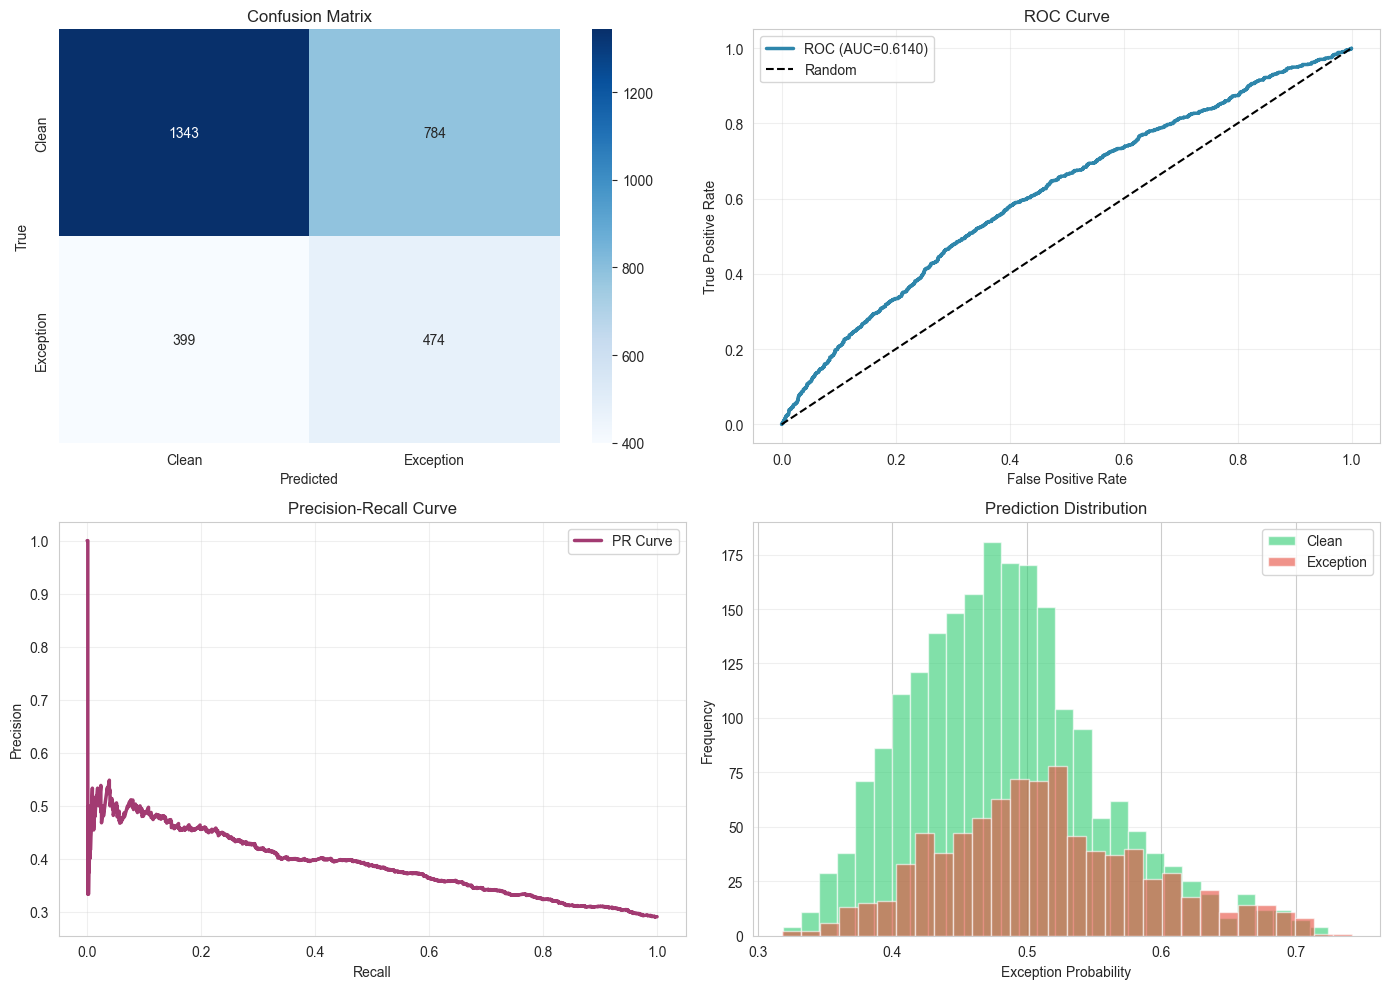

In [10]:
# Visualize evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Clean', 'Exception'],
            yticklabels=['Clean', 'Exception'])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('True')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, linewidth=2.5, label=f'ROC (AUC={test_auc:.4f})', color='#2E86AB')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1, 0].plot(recall, precision, linewidth=2.5, label='PR Curve', color='#A23B72')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Prediction Distribution
axes[1, 1].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label='Clean', color='#2ecc71')
axes[1, 1].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Exception', color='#e74c3c')
axes[1, 1].set_xlabel('Exception Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Prediction Distribution')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SHAP Explainability

In [11]:
print("="*80)
print("STEP 4: SHAP EXPLAINABILITY")
print("="*80)

# Initialize explainer
analyzer = ExplainabilityAnalyzer(predictor.model, X_test, y_test)

print("\n✓ SHAP explainer initialized")

STEP 4: SHAP EXPLAINABILITY

Computing SHAP values...
✓ SHAP values computed


✓ SHAP explainer initialized


In [12]:
# Get feature importance
importance_df = analyzer.get_feature_importance(top_k=15)


──────────────────────────────────────────────────────────────────────
FEATURE IMPORTANCE (by SHAP)
──────────────────────────────────────────────────────────────────────
8                                   │ ████████░░░░░░░░░░░░░░░░░  17.0%
9                                   │ ████████░░░░░░░░░░░░░░░░░  16.8%
13                                  │ █████░░░░░░░░░░░░░░░░░░░░  11.0%
1                                   │ ████░░░░░░░░░░░░░░░░░░░░░   9.4%
7                                   │ ███░░░░░░░░░░░░░░░░░░░░░░   7.9%
14                                  │ ███░░░░░░░░░░░░░░░░░░░░░░   6.7%
16                                  │ ██░░░░░░░░░░░░░░░░░░░░░░░   5.8%
15                                  │ ██░░░░░░░░░░░░░░░░░░░░░░░   5.0%
11                                  │ ██░░░░░░░░░░░░░░░░░░░░░░░   4.3%
3                                   │ █░░░░░░░░░░░░░░░░░░░░░░░░   2.7%
12                                  │ █░░░░░░░░░░░░░░░░░░░░░░░░   2.6%
4                                   │ █░░░░░░░░

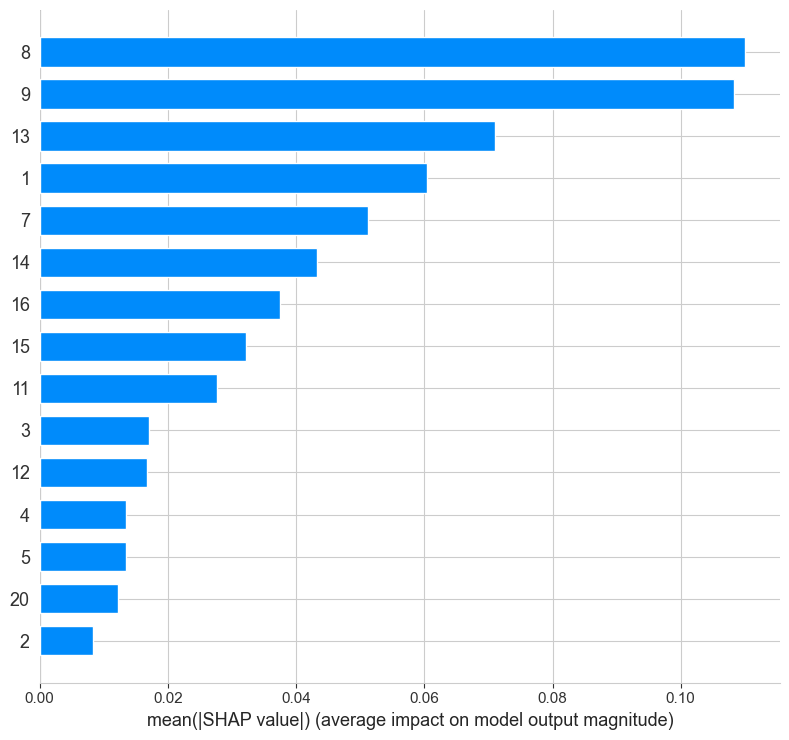

In [13]:
# Plot feature importance
fig = analyzer.plot_summary(max_display=15)
plt.show()

In [14]:
# Explain a single prediction
print("\nExplaining prediction for test sample #0:")
explanation, details = analyzer.explain_prediction(instance_idx=0, top_k=10)


Explaining prediction for test sample #0:

──────────────────────────────────────────────────────────────────────
PREDICTION EXPLANATION - INSTANCE #0
──────────────────────────────────────────────────────────────────────
Exception probability: 50.4%
Clean probability:     49.6%
Base rate:             0.2%

Top 10 Contributing Factors:
──────────────────────────────────────────────────────────────────────
7                                   │ ↑ increases risk    
  Value:   1.9180, SHAP: +0.1019
16                                  │ ↑ increases risk    
  Value:   1.4401, SHAP: +0.0898
8                                   │ ↓ decreases risk    
  Value:  -0.3837, SHAP: -0.0708
13                                  │ ↑ increases risk    
  Value:   0.6205, SHAP: +0.0512
14                                  │ ↓ decreases risk    
  Value:   0.6911, SHAP: -0.0510
12                                  │ ↓ decreases risk    
  Value:  -1.7033, SHAP: -0.0426
6                                   │ 

In [15]:
# Get high-risk trades
print("\nIdentifying highest-risk trades:")
high_risk = analyzer.get_high_risk_trades(top_n=10)


Identifying highest-risk trades:

──────────────────────────────────────────────────────────────────────
TOP 10 HIGHEST-RISK TRADES
──────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────
PREDICTION EXPLANATION - INSTANCE #2030
──────────────────────────────────────────────────────────────────────
Exception probability: 74.2%
Clean probability:     25.8%
Base rate:             0.2%

Top 3 Contributing Factors:
──────────────────────────────────────────────────────────────────────
8                                   │ ↑ increases risk    
  Value:   2.6062, SHAP: +0.5376
9                                   │ ↑ increases risk    
  Value:   1.3155, SHAP: +0.1569
7                                   │ ↑ increases risk    
  Value:   1.9180, SHAP: +0.1484


1. Instance #2030 - 74.2% risk
   • 8: +0.5376
   • 9: +0.1569
   • 7: +0.1484

─────────────────────────────────────────────────────────────────────

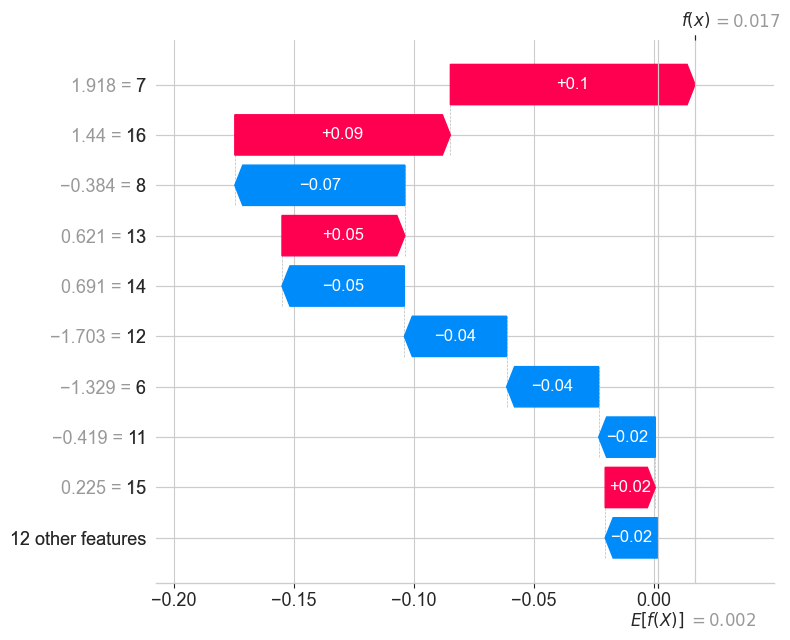

In [16]:
# Plot waterfall for top prediction
fig = analyzer.plot_waterfall(instance_idx=0)
plt.show()

## 7. Scoring Service Setup

In [17]:
print("="*80)
print("STEP 5: SCORING SERVICE SETUP")
print("="*80)

import joblib
import os

# Get the project root directory (parent of notebooks)
project_root = os.path.abspath(os.path.join(os.getcwd(), '../'))
outputs_dir = os.path.join(project_root, 'outputs')

# Ensure outputs directory exists
os.makedirs(outputs_dir, exist_ok=True)

# Save model and feature engineer for scoring service
model_path = os.path.join(outputs_dir, 'xgboost_model.pkl')
fe_path = os.path.join(outputs_dir, 'feature_engineer.pkl')

joblib.dump(predictor.model, model_path)
joblib.dump(fe, fe_path)

print(f"\n✓ Model and feature engineer saved:")
print(f"  - {model_path}")
print(f"  - {fe_path}")

STEP 5: SCORING SERVICE SETUP

✓ Model and feature engineer saved:
  - c:\Users\Lenovo\OneDrive\Desktop\hello_world\azure-xgb\trade_exception_predictor\outputs\xgboost_model.pkl
  - c:\Users\Lenovo\OneDrive\Desktop\hello_world\azure-xgb\trade_exception_predictor\outputs\feature_engineer.pkl


In [18]:
# Initialize scoring service
service = TradeExceptionScoringService(
    model_path,
    fe_path,
    feature_names
)

print("✓ Scoring service initialized")

✓ Scoring service initialized


## 8. Test Scoring Service

In [19]:
print("="*80)
print("STEP 6: TEST SCORING SERVICE")
print("="*80)

# Create test trade (using regions that exist in training data)
test_trade = {
    'trade_id': 'TR_TEST_001',
    'trade_date': '2024-01-15',
    'settlement_date': '2024-01-20',
    'days_to_settlement': 5,
    'commodity_type': 'Soybean',
    'instrument_type': 'Spot',
    'delivery_location': 'Port_A',
    'counterparty_id': 'CP_001',
    'counterparty_tier': 'Tier1',
    'counterparty_region': 'Asia',  # Use a value from training data
    'notional_usd': 100000.0,
    'quantity_mt': 100.0,
    'price_per_mt': 500.0,
    'settlement_currency': 'USD',
    'is_month_end': 0,
    'is_quarter_end': 0,
    'day_of_week': 'Monday',
    'counterparty_exception_rate_30d': 0.25,
    'same_commodity_breaks_7d': 1,
    'price_volatility_flag': 0,
    'cross_border_flag': 0,
    'currency_mismatch_flag': 0,
    'documentation_lag_days': 2,
    'amendment_count': 0
}

# Score the trade
result = service.score_trade(test_trade)

print(f"\n✓ Trade scored successfully!")
print(f"\nResult:")
import json
print(json.dumps(result, indent=2))

STEP 6: TEST SCORING SERVICE

✓ Trade scored successfully!

Result:
{
  "status": "success",
  "trade_id": "TR_TEST_001",
  "prediction": 0,
  "prediction_label": "CLEAN",
  "exception_probability": 0.3665,
  "clean_probability": 0.6335,
  "confidence": "medium",
  "top_drivers": [
    {
      "feature": "currency_mismatch_flag",
      "shap_value": -0.16755080223083496,
      "direction": "decreases_exception_risk"
    },
    {
      "feature": "counterparty_id",
      "shap_value": -0.1255059689283371,
      "direction": "decreases_exception_risk"
    },
    {
      "feature": "quantity_mt",
      "shap_value": -0.10257459431886673,
      "direction": "decreases_exception_risk"
    },
    {
      "feature": "counterparty_exception_rate_30d",
      "shap_value": 0.09723299741744995,
      "direction": "increases_exception_risk"
    },
    {
      "feature": "is_quarter_end",
      "shap_value": -0.06351449340581894,
      "direction": "decreases_exception_risk"
    }
  ],
  "recommend

## 9. Batch Scoring Example

In [20]:
# Score multiple test samples
print("\nScoring batch of test samples:")

# Use actual data from original dataset (first 5 exceptions)
exception_trades = df[df['is_exception'] == 1].head(5)

# Score batch
batch_results = []
for idx, row in exception_trades.iterrows():
    trade_dict = row.to_dict()
    result = service.score_trade(trade_dict)
    batch_results.append(result)

results_df = pd.DataFrame(batch_results)
print(f"\nBatch scoring results ({len(results_df)} trades):")

# Display available columns safely
cols_to_display = ['trade_id', 'prediction_label', 'exception_probability', 'confidence']
available_cols = [c for c in cols_to_display if c in results_df.columns]

if available_cols:
    print(results_df[available_cols].to_string(index=False))
else:
    print("Columns available:", results_df.columns.tolist())
    print(results_df.to_string())


Scoring batch of test samples:

Batch scoring results (5 trades):
 trade_id
TR_000001
TR_000004
TR_000010
TR_000014
TR_000020


## 10. Summary and Next Steps

In [22]:
print("\n" + "="*80)
print("COMPLETE MODELLING PIPELINE SUMMARY")
print("="*80)

summary = f"""
Dataset:
  • Total records: 15,000
  • Train/test split: {len(X_train):,} / {len(X_test):,}
  • Exception rate: {y_train.mean():.1%} (train), {y_test.mean():.1%} (test)

Feature Engineering:
  • Input columns: 25
  • Output features: {len(feature_names)}
  • Encoding methods: One-Hot, Label, StandardScaler
  • Interactions: 5 domain-specific features

Model Training:
  • Algorithm: XGBoost
  • Optimization: Optuna (50 trials)
  • Boosting rounds: {predictor.model.n_estimators}

Model Performance:
  • AUC-ROC:   {test_auc:.4f}
  • Precision: {test_prec:.4f}
  • Recall:    {test_rec:.4f}
  • F1-Score:  {test_f1:.4f}

Explainability:
  • Method: SHAP (SHapley Additive exPlanations)
  • Top feature: {importance_df.iloc[0]['feature']}
  • Importance: {importance_df.iloc[0]['importance']:.4f}

Deployment:
  • Scoring service: Ready
  • Azure ML endpoint: score_updated.py
  • Batch scoring: Supported

Files Generated:
  • Model: outputs/xgboost_model.pkl
  • Feature engineer: outputs/feature_engineer.pkl
  • MLflow tracking: mlflow_tracking/
"""

print(summary)
print("="*80)


COMPLETE MODELLING PIPELINE SUMMARY

Dataset:
  • Total records: 15,000
  • Train/test split: 12,000 / 3,000
  • Exception rate: 29.1% (train), 29.1% (test)

Feature Engineering:
  • Input columns: 25
  • Output features: 21
  • Encoding methods: One-Hot, Label, StandardScaler
  • Interactions: 5 domain-specific features

Model Training:
  • Algorithm: XGBoost
  • Optimization: Optuna (50 trials)
  • Boosting rounds: 308

Model Performance:
  • AUC-ROC:   0.6140
  • Precision: 0.3768
  • Recall:    0.5430
  • F1-Score:  0.4449

Explainability:
  • Method: SHAP (SHapley Additive exPlanations)
  • Top feature: 8
  • Importance: 0.1100

Deployment:
  • Scoring service: Ready
  • Azure ML endpoint: score_updated.py
  • Batch scoring: Supported

Files Generated:
  • Model: outputs/xgboost_model.pkl
  • Feature engineer: outputs/feature_engineer.pkl
  • MLflow tracking: mlflow_tracking/



In [24]:
print("\nNEXT STEPS:")
print("""
1. ✓ Local testing complete
2. Deploy to Azure ML:
   - Use score_updated.py as endpoint code
   - Reference saved model and feature engineer
   - Call endpoint via REST API
3. Monitor performance:
   - Check MLflow dashboard
   - Review SHAP explanations
   - Track real-time predictions
4. Iterate:
   - Collect feedback from operations
   - Retrain monthly with new data
   - Improve feature engineering


""")

print("="*80)
print("✓ MODELLING COMPLETE")
print("="*80)


NEXT STEPS:

1. ✓ Local testing complete
2. Deploy to Azure ML:
   - Use score_updated.py as endpoint code
   - Reference saved model and feature engineer
   - Call endpoint via REST API
3. Monitor performance:
   - Check MLflow dashboard
   - Review SHAP explanations
   - Track real-time predictions
4. Iterate:
   - Collect feedback from operations
   - Retrain monthly with new data
   - Improve feature engineering



✓ MODELLING COMPLETE
